<a href="https://colab.research.google.com/github/AbdullahRasheed452/ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [11]:
import os, subprocess

REPO_URL = "https://github.com/AbdullahRasheed452/ML-Internship"
REPO_DIR = "ML-Internship"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
if os.getcwd().split("/")[-1] != REPO_DIR:
    os.chdir(REPO_DIR)

In [12]:
%pip -q install -U duckdb huggingface_hub

In [13]:
import os, getpass

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('HF_TOKEN')

In [14]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients': f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content': f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily': f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
}

In [15]:
# Build the same features used in Week 5 and Week 6
# Only first half of March is used for features, so nothing about the
# second half, which defines the label, leaks in
q = f"""
SELECT
    f.content_hash_id,
    f.client_hash_id,
    AVG(CASE WHEN f.report_date < '2026-03-16' THEN f.gsc_impressions END) AS avg_impressions_first_half,
    AVG(CASE WHEN f.report_date < '2026-03-16' THEN f.gsc_avg_position END) AS avg_position_first_half,
    AVG(CASE WHEN f.report_date < '2026-03-16' AND f.gsc_impressions > 0
             THEN f.gsc_clicks * 1.0 / f.gsc_impressions END) AS avg_ctr_first_half,
    ANY_VALUE(c.word_count) AS word_count,
    ANY_VALUE(DATE_DIFF('day', c.content_created_date, DATE '2026-03-15')) AS content_age_days,
    SUM(CASE WHEN f.report_date < '2026-03-16' THEN f.gsc_impressions ELSE 0 END) AS imp_first_half,
    SUM(CASE WHEN f.report_date >= '2026-03-16' THEN f.gsc_impressions ELSE 0 END) AS imp_second_half
FROM {TABLES['fact_daily']} f
JOIN {TABLES['dim_content']} c ON f.content_hash_id = c.content_hash_id
WHERE f.report_date >= '2026-03-01' AND f.report_date < '2026-04-01'
GROUP BY f.content_hash_id, f.client_hash_id
HAVING imp_first_half >= 10
"""

model_data = con.sql(q).df()

# Same decline label as before, impressions dropped more than 20 percent
model_data['pct_change'] = (model_data['imp_second_half'] - model_data['imp_first_half']) / model_data['imp_first_half']
model_data['is_declining'] = (model_data['pct_change'] < -0.2).astype(int)
model_data = model_data.dropna(subset=['avg_impressions_first_half', 'avg_position_first_half', 'avg_ctr_first_half', 'word_count', 'content_age_days'])

print(len(model_data), 'pages,', model_data['client_hash_id'].nunique(), 'clients')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

79616 pages, 41 clients


In [16]:
# Split by client, same honest split as Week 6, so no client appears
# in both train and test
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

features = ['avg_impressions_first_half', 'avg_position_first_half', 'avg_ctr_first_half', 'word_count', 'content_age_days']
X = model_data[features]
y = model_data['is_declining']
groups = model_data['client_hash_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print('model trained on', len(X_train), 'pages')

model trained on 61691 pages


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [17]:
# Build the ranked queue on the test set, the pages the model has not
# memorized from training
import pandas as pd
import numpy as np

queue = model_data.iloc[test_idx].copy()
queue['decline_score'] = rf.predict_proba(X_test)[:, 1]

# Reason codes, simple rules a human can check at a glance
def get_reason_code(row):
    if row['avg_position_first_half'] <= 20 and row['avg_ctr_first_half'] < 0.005:
        return 'low_ctr_for_position'
    elif row['content_age_days'] >= 270:
        return 'aging_content_risk'
    elif row['avg_impressions_first_half'] >= 100 and row['decline_score'] >= 0.5:
        return 'visible_page_declining'
    else:
        return 'general_decline_risk'

queue['reason_code'] = queue.apply(get_reason_code, axis=1)

# Action label, plain instruction a reviewer can act on
action_map = {
    'low_ctr_for_position': 'review title and meta description',
    'aging_content_risk': 'schedule a content refresh',
    'visible_page_declining': 'prioritize for review this week',
    'general_decline_risk': 'monitor, low urgency'
}
queue['action'] = queue['reason_code'].map(action_map)

queue = queue.sort_values('decline_score', ascending=False)

print(len(queue), 'pages ranked')
queue[['content_hash_id', 'decline_score', 'reason_code', 'action']].head(10)

17925 pages ranked


,content_hash_id,decline_score,reason_code,action
53393,content_3e0bdfaf99e333d5,0.995,low_ctr_for_position,review title and meta description
54423,content_f299f5bd8001ba7f,0.965,low_ctr_for_position,review title and meta description
113604,content_3faf429767ce0753,0.965,low_ctr_for_position,review title and meta description
119117,content_54fe56ede54646f7,0.955,low_ctr_for_position,review title and meta description
59222,content_5d0a9b7893b8a30a,0.930,low_ctr_for_position,review title and meta description
53504,content_51489ac2871e8919,0.925,low_ctr_for_position,review title and meta description
53876,content_92f8a3d3e777821d,0.925,low_ctr_for_position,review title and meta description
54535,content_0ab6d2e6aa741ffc,0.925,general_decline_risk,"monitor, low urgency"
21603,content_7e57c56251b6e159,0.905,low_ctr_for_position,review title and meta description
11390,content_fa1f6dd97064bd29,0.900,low_ctr_for_position,review title and meta description


In [18]:
# Section 1: Ranked actions + reason codes
# 17,925 pages ranked by decline risk, each with a reason code and
# a plain action a reviewer can take

# low_ctr_for_position: good rank but low clicks, review title and meta
# aging_content_risk: over 270 days old, schedule a refresh
# visible_page_declining: real traffic and high risk, prioritize this week
# general_decline_risk: lower confidence, just monitor

# Most top pages are low_ctr_for_position, matching what the Week 4 baseline already found

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [19]:
# Who this is for: a content reviewer or SEO analyst deciding which
# pages to check first when time is limited

# What it does: ranks pages by decline risk and gives a reason code,
# so review time goes to the pages most likely to need attention

# What it does not do:
# It does not guarantee a page is actually declining, only that it
# matches a pattern seen in past data
# It does not prove that fixing a flagged page will improve its traffic
# It is not tested outside March 2026 data, so results on other months
# or new clients are not guaranteed to hold
# It should not be treated as a ranking of content quality, only of risk pattern

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [20]:
# What a person must check before acting:
# Confirm the page still has real traffic, not just historical data
# Check if the decline lines up with a known site change, like a
# redesign or a competing page on the same site
# Read the actual page before assuming the reason code tells the whole story

# What should never be automated:
# Auto deleting or unpublishing a page based on this score
# Auto rewriting content without a human reviewing it first
# Treating the score as a public claim about content quality
# Making client facing promises based on this score alone

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [21]:
# Retrain the model if:
# Precision@50 drops noticeably when checked against a newer month
# A new client is added with very different traffic patterns than the clients used in training
# The site or product changes in a way that shifts what counts as a
# normal position or CTR, like a major search algorithm update

# Simple ongoing check:
# Every month, rerun the model on the newest data and compare its
# Precision@50 to this month's baseline of 0.700
# If it drops well below that for two months in a row, treat it as a signal to review and retrain

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [22]:
import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the ranked queue, this file stays out of git by design
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Saved {len(queue)} rows to work/outputs/action_playbook_queue.csv")

Saved 17925 rows to work/outputs/action_playbook_queue.csv


In [23]:
# Save a small metrics file as a receipt for the paper, this one gets committed
import json

metrics = {
    "model": "Random Forest",
    "split": "grouped by client",
    "precision_at_20": 0.650,
    "precision_at_50": 0.700,
    "baseline_precision_at_20": 0.300,
    "baseline_precision_at_50": 0.260,
    "total_pages_ranked": len(queue),
    "month_used": "2026-03"
}

with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics json")

Saved metrics json


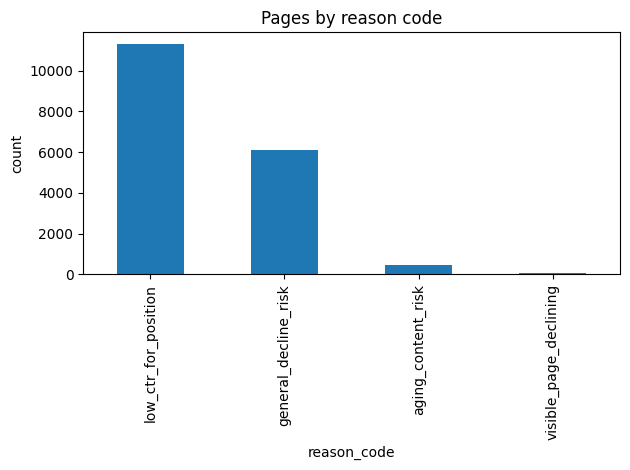

In [24]:
# Save a simple bar chart of reason code counts, a figure the paper can reuse
import matplotlib.pyplot as plt

reason_counts = queue['reason_code'].value_counts()
reason_counts.plot(kind='bar')
plt.title('Pages by reason code')
plt.ylabel('count')
plt.tight_layout()
plt.savefig("work/figures/reason_code_counts.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.